# Projet G13 - Exploration du Dataset Emotion Detection

Ce notebook explore le dataset et montre quelques exemples

In [1]:
import sys
sys.path.insert(0, '..')

from src import data_loader
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

c:\Users\DELL\anaconda3\envs\mlop\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Charger le dataset complet

In [2]:
from datasets import load_dataset

# Charger le dataset complet
dataset = load_dataset('emotion')
print(f"Dataset keys: {dataset.keys()}")
print(f"Train size: {len(dataset['train'])}")
print(f"Validation size: {len(dataset['validation'])}")
print(f"Test size: {len(dataset['test'])}")

Dataset keys: dict_keys(['train', 'validation', 'test'])
Train size: 16000
Validation size: 2000
Test size: 2000


## Afficher les 6 classes d'émotions

In [3]:
label_names = data_loader.get_label_names()
print("Classes d'émotions:")
for idx, name in label_names.items():
    print(f"  {idx}: {name}")

Classes d'émotions:
  0: sadness
  1: joy
  2: love
  3: anger
  4: fear
  5: surprise


## Distribution des classes dans le dataset complet

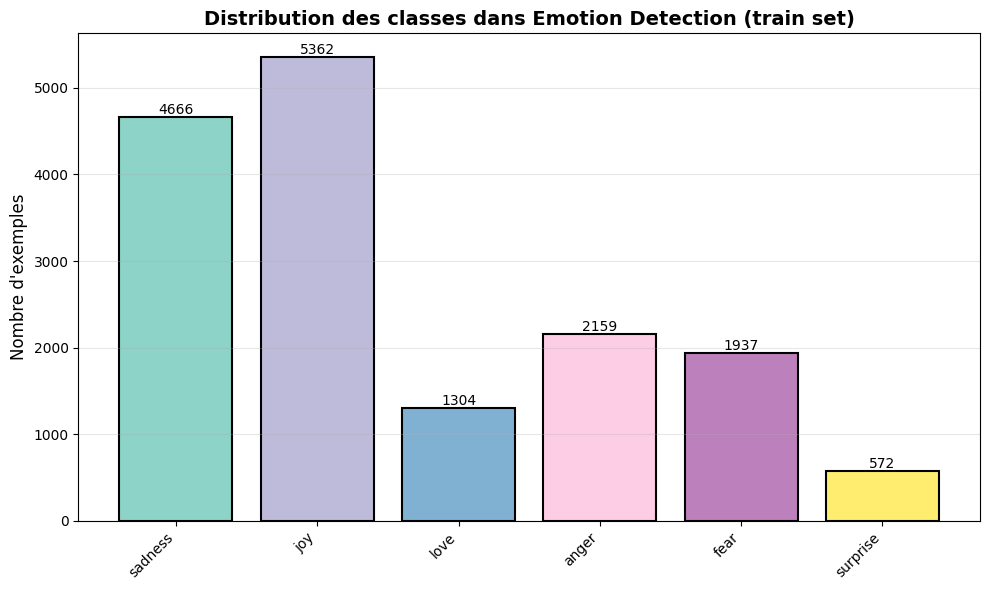


Distribution:
  sadness: 4666 (29.2%)
  joy: 5362 (33.5%)
  love: 1304 (8.2%)
  anger: 2159 (13.5%)
  fear: 1937 (12.1%)
  surprise: 572 (3.6%)


In [4]:
# Compter les labels
labels = [ex['label'] for ex in dataset['train']]
label_counts = Counter(labels)

# Afficher la distribution
emotions = [label_names[i] for i in range(6)]
counts = [label_counts[i] for i in range(6)]

plt.figure(figsize=(10, 6))
colors = plt.cm.Set3(np.linspace(0, 1, 6))
plt.bar(emotions, counts, color=colors, edgecolor='black', linewidth=1.5)
plt.ylabel('Nombre d\'exemples', fontsize=12)
plt.title('Distribution des classes dans Emotion Detection (train set)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# Ajouter les nombres sur les barres
for emotion, count in zip(emotions, counts):
    plt.text(emotion, count, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nDistribution:")
for emotion, count in zip(emotions, counts):
    print(f"  {emotion}: {count} ({100*count/len(labels):.1f}%)")

## Afficher quelques exemples de textes

In [5]:
print("Exemples de textes par classe:\n")

for label_id in range(6):
    # Trouver un exemple de cette classe
    example = next(ex for ex in dataset['train'] if ex['label'] == label_id)
    print(f"{'='*70}")
    print(f"Classe: {label_names[label_id].upper()}")
    print(f"{'='*70}")
    print(f"Texte: {example['text']}")
    print(f"Label: {label_id}")
    print()

Exemples de textes par classe:

Classe: SADNESS
Texte: i didnt feel humiliated
Label: 0

Classe: JOY
Texte: i have been with petronas for years i feel that petronas has performed well and made a huge profit
Label: 1

Classe: LOVE
Texte: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Label: 2

Classe: ANGER
Texte: im grabbing a minute to post i feel greedy wrong
Label: 3

Classe: FEAR
Texte: i feel as confused about life as a teenager or as jaded as a year old man
Label: 4

Classe: SURPRISE
Texte: ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny
Label: 5



## Statistiques des textes

Statistiques des textes:
  Nombre de mots moyen: 19.2
  Min: 2, Max: 66
  Médiane: 17.0
  Percentile 95: 41.0


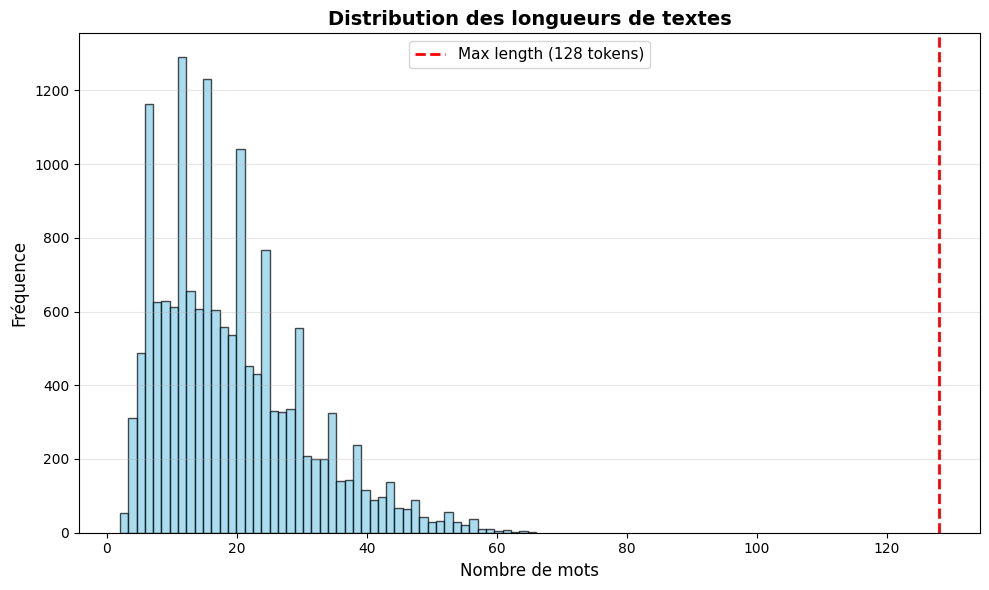

In [6]:
# Longueur des textes
texts = [ex['text'] for ex in dataset['train']]
lengths = [len(text.split()) for text in texts]

print(f"Statistiques des textes:")
print(f"  Nombre de mots moyen: {np.mean(lengths):.1f}")
print(f"  Min: {np.min(lengths)}, Max: {np.max(lengths)}")
print(f"  Médiane: {np.median(lengths):.1f}")
print(f"  Percentile 95: {np.percentile(lengths, 95):.1f}")

plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=50, edgecolor='black', color='skyblue', alpha=0.7)
plt.xlabel('Nombre de mots', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.title('Distribution des longueurs de textes', fontsize=14, fontweight='bold')
plt.axvline(128, color='red', linestyle='--', linewidth=2, label='Max length (128 tokens)')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Charger et afficher les données préparées

In [7]:
# Charger le dataset avec le subset
train_loader, val_loader, num_classes, tokenizer = data_loader.load_emotion_dataset(
    subset_size=500,
    val_size=100,
    batch_size=16
)

print(f"Train loader batches: {len(train_loader)}")
print(f"Val loader batches: {len(val_loader)}")
print(f"Num classes: {num_classes}")

Train loader batches: 25
Val loader batches: 7
Num classes: 6


## Afficher un batch préparé

In [8]:
# Afficher le premier batch
batch = next(iter(train_loader))

print(f"Shapes du batch:")
print(f"  input_ids: {batch['input_ids'].shape}")
print(f"  attention_mask: {batch['attention_mask'].shape}")
print(f"  labels: {batch['labels'].shape}")

print(f"\nPrenier exemple du batch:")
print(f"  input_ids: {batch['input_ids'][0]}")
print(f"  attention_mask: {batch['attention_mask'][0]}")
print(f"  label: {batch['labels'][0].item()}")

Shapes du batch:
  input_ids: torch.Size([16, 128])
  attention_mask: torch.Size([16, 128])
  labels: torch.Size([16])

Prenier exemple du batch:
  input_ids: tensor([  101,  2043,  2026, 12954,  2015,  2567,  2979,  2185,  2044,  2383,
         2042,  2920,  1999,  1037,  2482,  4926,  2002,  2001,  5026,  2033,
         1037,  2556,  2004,  1045,  2018,  2979,  2026,  2433,  2274, 13869,
         2007,  3909,  8604,   102,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     